# Understanding the SMC's DM profile evolution in response to LMC's tides

Using the semi-analytic model of Du+2024 PRD 110, 023019 (2024)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plots_init as pi
from matplotlib import cm
from matplotlib.colors import Normalize

## Required function definitions

The Du+2024 framework describes the evolution of the following paramaters of a tidally disrupting halo:
$$\delta v = \frac{v_{\rm max}}{v_{\rm max, 0}}$$
$$\delta R = \frac{R_{\rm max}}{R_{\rm max, 0}}$$
$$\delta M = \frac{M_{\rm bound}}{M_{\rm bound, 0}}$$
Where, $v_{\rm max}$ denotes the maximum rotational velocity of the halo at any given stage of tidal disruption, and $v_{\rm max, 0}$ denotes the maximum rotational velocity initially. $R_{\rm max}$ is the radius at which the rotation velocity attains a maximum, and $M_{\rm bound}$ is the bound mass of the halo. $\delta v$ and $\delta R$ are expressed as a function of $\delta M$. This work argued that this function depends only on the dark matter profile, and is different for cored and cusped profiles. We will extract the functional forms for cored and cusped profile from that paper.

In [3]:
def delta_v_cored(delta_m):
    dv = (2**0.83)*(delta_m**0.42)/((1 + delta_m)**0.83)
    return dv

def delta_v_cusped(delta_m):
    dv = (2**0.34)*(delta_m**0.17)/((1 + delta_m)**0.34)
    return dv

def delta_r_cored(delta_m):
    dr = (2**(-0.37))*(delta_m**0.20)/((1 + delta_m)**(-0.37))
    return dr

def delta_r_cusped(delta_m):
    dr = (2**1.21)*(delta_m**0.68)/((1 + delta_m)**(1.21))
    return dr

## Plotting

For the initial values $v_{\rm max, 0}$, $R_{\rm max, 0}$ and $M_{bound, 0}$, we will use the Besla et al. 2012 [MNRAS 421 2109] simulated SMC, prior to the LMC-SMC collision. We will multiply $\delta v$, $\delta R$ and $\delta M$ by these values to convert the relative quantities to absolute. The observed uncertainties on the above quantities are estimated using the "specs5_prediction_smc_tidal_radius_vrad.ipynb" notebook.

In [4]:
v_max0 = 36 #km/s
R_max0 = 3.3 #kpc
M_bound0 = 4e9 #Msun

delta_m_array = np.linspace(0.1, 0.5, 300)
dv_cored_array = delta_v_cored(delta_m_array) * v_max0
dv_cusped_array = delta_v_cusped(delta_m_array) * v_max0
dr_cored_array = delta_r_cored(delta_m_array) * R_max0
dr_cusped_array = delta_r_cusped(delta_m_array) * R_max0
delta_m_array = delta_m_array*M_bound0

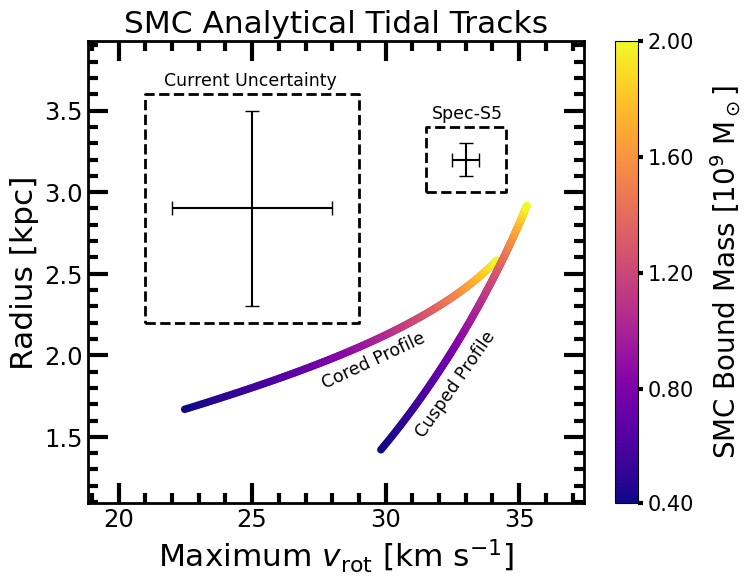

In [5]:
fig = plt.figure(figsize=(8, 6))
ax0 = fig.add_subplot(1, 1, 1)

# Create normalization object for delta_m_array values
norm = Normalize(vmin=delta_m_array.min(), vmax=delta_m_array.max())

# Plot as scatter with connecting lines
scatter_cored = ax0.scatter(dv_cored_array, dr_cored_array, c=delta_m_array, cmap='plasma', 
                            norm=norm, label="Cored Profile", s=20, zorder=3)
ax0.plot(dv_cored_array, dr_cored_array, alpha=0.3, color='gray', zorder=1)

scatter_cusped = ax0.scatter(dv_cusped_array, dr_cusped_array, c=delta_m_array, cmap='plasma', 
                             norm=norm, label="Cusped Profile", s=20, zorder=3)
ax0.plot(dv_cusped_array, dr_cusped_array, alpha=0.3, color='gray', zorder=1)

ax0.set_xlabel(r"Maximum $v_{\rm rot}$ [km s$^{-1}$]")
ax0.set_ylabel(r"Radius [kpc]")
ax0.annotate("Cored Profile", (27.5, 1.8), rotation = 25, fontsize = 12.5)
ax0.annotate("Cusped Profile", (31, 1.5), rotation = 55, fontsize = 12.5)
ax0.errorbar(25, 2.9, xerr = 3, yerr = 0.6, color = "k", capsize = 5)
ax0.errorbar(33, 3.2, xerr = 0.5, yerr = 0.1, color = "k", capsize = 5)
ax0.annotate("Current Uncertainty", (21.7, 3.65), fontsize = 12.5)
ax0.annotate("Spec-S5", (31.75, 3.45), fontsize = 12.5)

x = [21, 29, 29, 21, 21]
y = [2.2, 2.2, 3.6, 3.6, 2.2]
# Plot the lines connecting the coordinates
plt.plot(x, y, 'k', linewidth=2, linestyle = "--")

x = [31.5, 34.5, 34.5, 31.5, 31.5]
y = [3, 3, 3.40, 3.40, 3]
# Plot the lines connecting the coordinates
plt.plot(x, y, 'k', linewidth=2, linestyle = "--")

# Add colorbar with custom ticks matching delta_m_array values
cbar = fig.colorbar(scatter_cored, ax=ax0)
cbar.set_label(r'SMC Bound Mass [10$^9$ M$_\odot]$', labelpad = 10, size = 20)
# Set colorbar ticks to specific delta_m values
tick_indices = np.linspace(0, len(delta_m_array)-1, 5, dtype=int)
cbar.set_ticks(delta_m_array[tick_indices])
cbar.set_ticklabels([f'{val:.2f}' for val in np.round(delta_m_array[tick_indices]/1e9, 2)])
cbar.ax.tick_params(labelsize = 15, width = 3)

ax0.set_title("SMC Analytical Tidal Tracks")

pi.aesthetic(ax0)
plt.savefig("smc_tidal_track.jpg", bbox_inches = "tight", dpi = 300)
plt.show()

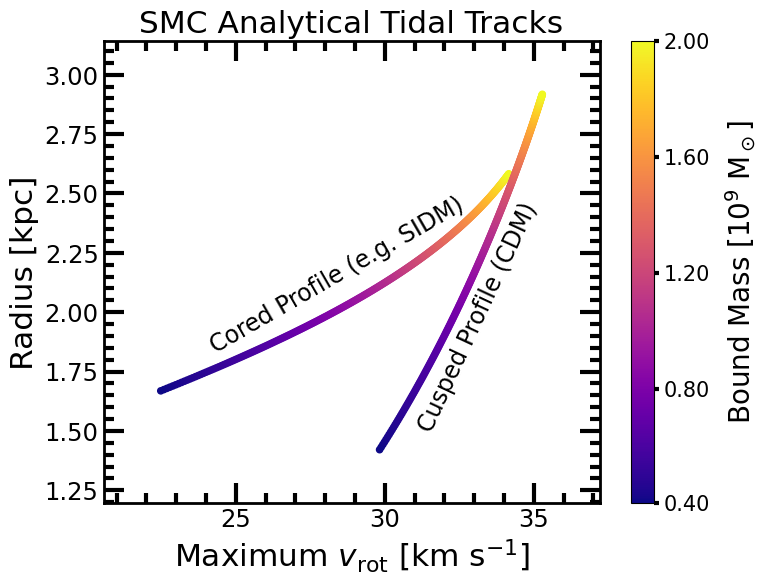

In [15]:
fig = plt.figure(figsize=(8, 6))
ax0 = fig.add_subplot(1, 1, 1)

# Create normalization object for delta_m_array values
norm = Normalize(vmin=delta_m_array.min(), vmax=delta_m_array.max())

# Plot as scatter with connecting lines
scatter_cored = ax0.scatter(dv_cored_array, dr_cored_array, c=delta_m_array, cmap='plasma', 
                            norm=norm, label="Cored Profile", s=20, zorder=3)
ax0.plot(dv_cored_array, dr_cored_array, alpha=0.3, color='gray', zorder=1)

scatter_cusped = ax0.scatter(dv_cusped_array, dr_cusped_array, c=delta_m_array, cmap='plasma', 
                             norm=norm, label="Cusped Profile", s=20, zorder=3)
ax0.plot(dv_cusped_array, dr_cusped_array, alpha=0.3, color='gray', zorder=1)

ax0.set_xlabel(r"Maximum $v_{\rm rot}$ [km s$^{-1}$]")
ax0.set_ylabel(r"Radius [kpc]")
ax0.annotate("Cored Profile (e.g. SIDM)", (24, 1.83), rotation = 30, fontsize = 17)
ax0.annotate("Cusped Profile (CDM)", (31, 1.5), rotation = 65, fontsize = 17)

# Add colorbar with custom ticks matching delta_m_array values
cbar = fig.colorbar(scatter_cored, ax=ax0)
cbar.set_label(r'Bound Mass [10$^9$ M$_\odot]$', labelpad = 10, size = 20)
# Set colorbar ticks to specific delta_m values
tick_indices = np.linspace(0, len(delta_m_array)-1, 5, dtype=int)
cbar.set_ticks(delta_m_array[tick_indices])
cbar.set_ticklabels([f'{val:.2f}' for val in np.round(delta_m_array[tick_indices]/1e9, 2)])
cbar.ax.tick_params(labelsize = 15, width = 3)

ax0.set_title("SMC Analytical Tidal Tracks")

pi.aesthetic(ax0)
plt.savefig("smc_tidal_track_no_annotation.jpg", bbox_inches = "tight", dpi = 300)
plt.show()

## Radius v/s bound mass

In [6]:
"""
fig = plt.figure(figsize = (8, 6))
ax0 = fig.add_subplot(1, 1, 1)
ax0.plot(delta_m_array*2.2, dr_cored_array*3.3, label = "Cored Profile", linewidth = 3, linestyle = "--")
ax0.plot(delta_m_array*2.2, dr_cusped_array*3.3, label = "Cusped Profile", linewidth = 3)
#ax0.errorbar(0.034, )
ax0.set_xlabel(r"SMC Bound Mass [$10^9$ M$_\odot$]")
ax0.set_ylabel(r"SMC Tidal Radius [kpc]")
ax0.set_title("SMC's Analytical Tidal Track")
ax0.legend()
pi.aesthetic(ax0)
plt.show()
"""

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_2170419/980513039.py:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax0.set_xlabel(r"SMC Bound Mass [$10^9$ M$_\odot$]")


'\nfig = plt.figure(figsize = (8, 6))\nax0 = fig.add_subplot(1, 1, 1)\nax0.plot(delta_m_array*2.2, dr_cored_array*3.3, label = "Cored Profile", linewidth = 3, linestyle = "--")\nax0.plot(delta_m_array*2.2, dr_cusped_array*3.3, label = "Cusped Profile", linewidth = 3)\n#ax0.errorbar(0.034, )\nax0.set_xlabel(r"SMC Bound Mass [$10^9$ M$_\\odot$]")\nax0.set_ylabel(r"SMC Tidal Radius [kpc]")\nax0.set_title("SMC\'s Analytical Tidal Track")\nax0.legend()\npi.aesthetic(ax0)\nplt.show()\n'